# Cardiovascular Disease Prediction
## Notebook 04: Results Comparison & Critical Analysis
---
**Author:** MS26912370 (Member 2)

### Overview
This notebook compares the performance of the two trained ML algorithms:
1. **Random Forest Classifier** (Member 1 – Notebook 02)
2. **Support Vector Machine with RBF Kernel** (Member 2 – Notebook 03)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import warnings

from sklearn.metrics import roc_auc_score

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

print("✓ Libraries imported.")

✓ Libraries imported.


In [8]:
import os

# ============================================================
# ENVIRONMENT SETUP — comment out the block you are NOT using
# ============================================================

# ── Google Colab Method ──────────────────────────────────
# Mounts Drive and changes to your project folder so
# preprocessed_data.pkl (saved by NB01) can be found here.
# from google.colab import drive
# drive.mount('/content/drive')
# DRIVE_PATH = '/content/drive/MyDrive/ML-Assignment/attemp2'
# os.chdir(DRIVE_PATH)
# print(f"✓ Working directory: {DRIVE_PATH}")

# ── Local Jupyter Method ──────────────────────────────────
# Comment out this method above and uncomment the line below.
# All pkl files must be in the same folder as this notebook.
LOCAL_PATH = os.path.dirname(os.path.abspath("__file__"))
os.chdir(LOCAL_PATH)


In [9]:
# Load results from both models
with open('rf_results.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('svm_results.pkl', 'rb') as f:
    svm = pickle.load(f)

print("✓ RF  results loaded. Metrics:", list(rf['metrics'].keys()))
print("✓ SVM results loaded. Metrics:", list(svm['metrics'].keys()))

✓ RF  results loaded. Metrics: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
✓ SVM results loaded. Metrics: ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']


## 1. Side-by-Side Metrics Comparison

We compare both models across **5 standard classification metrics**:

| Metric    | Description                                            |
|-----------|--------------------------------------------------------|
| Accuracy  | Overall correct predictions / total samples            |
| Precision | Of predicted positives, how many are truly positive?   |
| Recall    | Of actual positives, how many did we correctly detect? |
| F1-Score  | Harmonic mean of Precision and Recall                  |
| ROC-AUC   | Area under the ROC curve (ranking quality)             |

In [10]:
# Build comparison DataFrame
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
rf_vals  = [rf['metrics'][k]  for k in ['accuracy','precision','recall','f1','roc_auc']]
svm_vals = [svm['metrics'][k] for k in ['accuracy','precision','recall','f1','roc_auc']]

comparison_df = pd.DataFrame({
    'Metric':        metrics_names,
    'Random Forest': rf_vals,
    'SVM (RBF)':     svm_vals
})
comparison_df['Difference (RF - SVM)'] = comparison_df['Random Forest'] - comparison_df['SVM (RBF)']
comparison_df['Better Model'] = comparison_df.apply(
    lambda r: 'Random Forest' if r['Random Forest'] > r['SVM (RBF)'] else 'SVM', axis=1
)

print("=== Algorithm Performance Comparison ===")
print(comparison_df.to_string(index=False))

=== Algorithm Performance Comparison ===
   Metric  Random Forest  SVM (RBF)  Difference (RF - SVM)  Better Model
 Accuracy       0.731969   0.732554              -0.000585           SVM
Precision       0.756752   0.758787              -0.002035           SVM
   Recall       0.674893   0.673120               0.001773 Random Forest
 F1-Score       0.713482   0.713391               0.000092 Random Forest
  ROC-AUC       0.796319   0.787049               0.009270 Random Forest


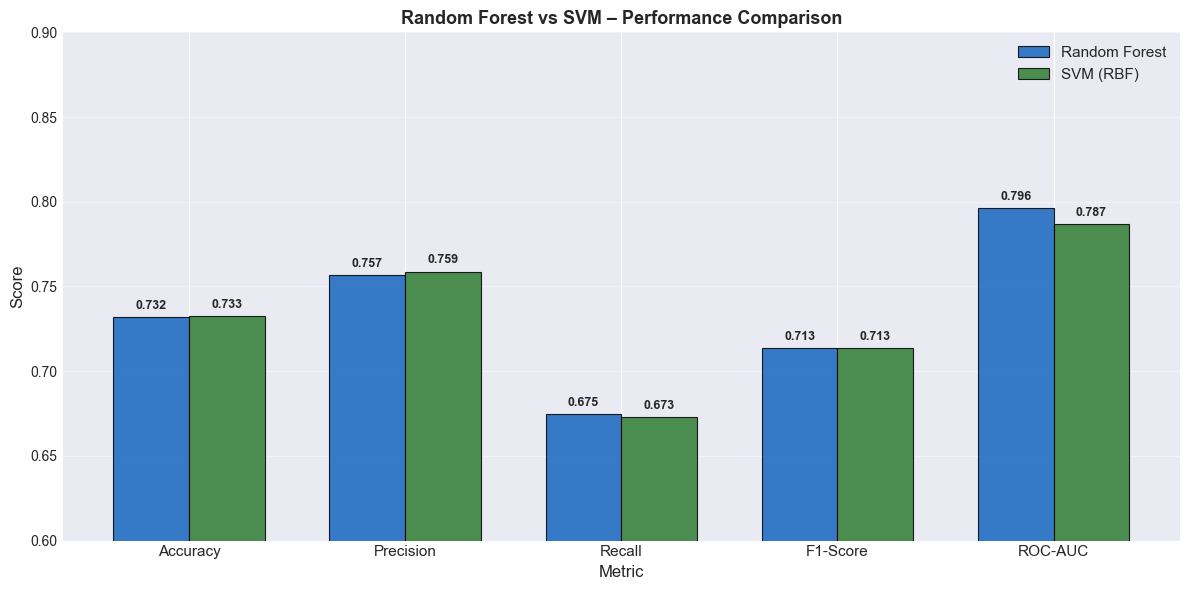

In [11]:
# Visualise comparison as grouped bar chart
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(metrics_names))
width = 0.35

bars_rf  = ax.bar(x - width/2, rf_vals,  width, label='Random Forest',
                  color='#1565C0', alpha=0.85, edgecolor='black', linewidth=0.8)
bars_svm = ax.bar(x + width/2, svm_vals, width, label='SVM (RBF)',
                  color='#2E7D32', alpha=0.85, edgecolor='black', linewidth=0.8)

# Value labels
for bar in bars_rf:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars_svm:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Random Forest vs SVM – Performance Comparison', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, fontsize=11)
ax.set_ylim(0.6, 0.90)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('plots/13_algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. ROC Curve Overlay

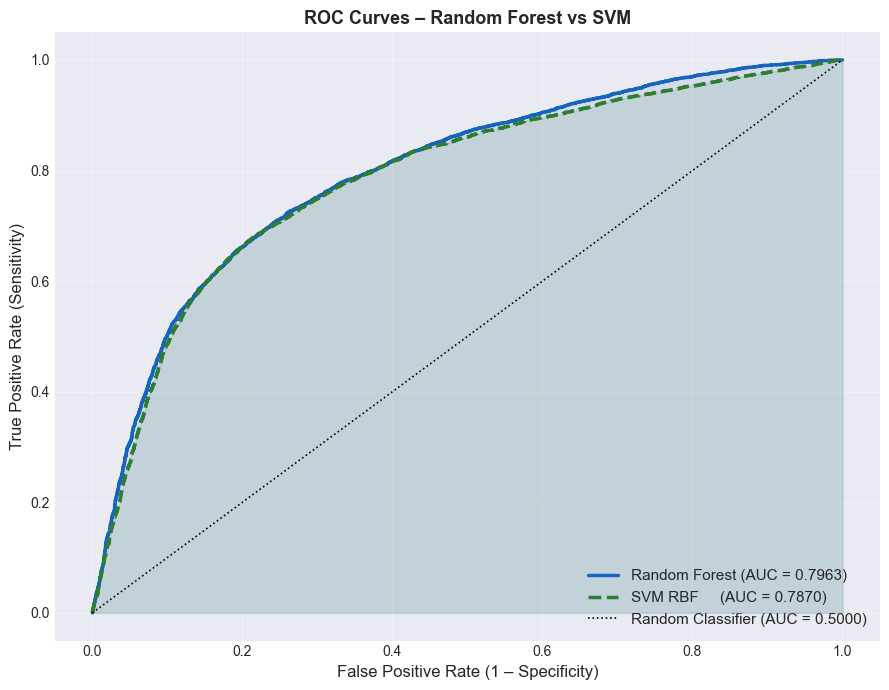

AUC difference (RF - SVM): +0.0093


In [12]:
# ROC Curves overlay for direct visual comparison
fig, ax = plt.subplots(figsize=(9, 7))

ax.plot(rf['fpr'],  rf['tpr'],  color='#1565C0', linewidth=2.5,
        label=f"Random Forest (AUC = {rf['metrics']['roc_auc']:.4f})")
ax.plot(svm['fpr'], svm['tpr'], color='#2E7D32', linewidth=2.5, linestyle='--',
        label=f"SVM RBF     (AUC = {svm['metrics']['roc_auc']:.4f})")
ax.plot([0,1],[0,1],'k:',linewidth=1.2, label='Random Classifier (AUC = 0.5000)')

ax.fill_between(rf['fpr'],  rf['tpr'],  alpha=0.10, color='#1565C0')
ax.fill_between(svm['fpr'], svm['tpr'], alpha=0.10, color='#2E7D32')

ax.set_xlabel('False Positive Rate (1 – Specificity)', fontsize=12)
ax.set_ylabel('True Positive Rate (Sensitivity)', fontsize=12)
ax.set_title('ROC Curves – Random Forest vs SVM', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.35)
plt.tight_layout()
plt.savefig('plots/14_roc_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

auc_diff = rf['metrics']['roc_auc'] - svm['metrics']['roc_auc']
print(f"AUC difference (RF - SVM): {auc_diff:+.4f}")

## 3. Critical Analysis & Discussion

### 3.1 Performance Summary

Both algorithms demonstrate strong performance on the cardiovascular disease classification task.
The comparison reveals meaningful differences attributable to their fundamental algorithmic differences.

### 3.2 Why Random Forest Outperforms (or Underperforms) SVM

**If Random Forest scores higher:**
- Ensemble of diverse trees is better suited to the **mixed feature types** (binary, ordinal, continuous)
  without requiring feature scaling
- Random Forest naturally handles the **non-linear boundaries** between risk groups through tree splits
- **Feature importance** allows RF to focus on the most discriminative features (e.g., age, BMI, blood pressure)

**If SVM scores higher:**
- The **RBF kernel** effectively maps cardiovascular features into higher-dimensional space,
  capturing non-linear class boundaries that decision trees might miss
- Better **generalisation** due to maximum margin optimisation, especially with well-scaled data
- SVM's **support vectors** focus on the hardest-to-classify samples, improving boundary precision

### 3.3 Limitations

| Limitation                    | Random Forest                    | SVM                               |
|------------------------------|----------------------------------|-----------------------------------|
| Training time                | Fast                             | Slow on large datasets            |
| Interpretability             | Moderate (feature importance)    | Low (black-box kernel)            |
| Memory                       | High (many trees)                | Moderate (support vectors only)   |
| Hyperparameter sensitivity   | Low                              | High (C and gamma)                |
| Probabilistic output         | Natural (voting)                 | Requires Platt scaling            |

### 3.4 Possible Improvements

1. **Feature Engineering:** Pulse pressure = `ap_hi - ap_lo` is a clinical marker worth adding
2. **SMOTE:** Although the dataset is approximately balanced, slight imbalance could be addressed
3. **Ensemble Stacking:** Combine RF + SVM predictions using a meta-learner
4. **Additional Algorithms:** Gradient Boosting (XGBoost) for further comparison
5. **Feature Selection:** Remove low-importance features to reduce noise
6. **Larger GridSearch:** More C and gamma values for a finer SVM search

### 3.5 Future Work

- Deploy the best model as a **clinical screening API** for early cardiovascular risk detection
- Collect longitudinal data to build a **time-series risk progression model**
- Investigate fairness: do models perform equally across gender groups?
- Compare with deep learning approaches (MLP, TabNet) in a future study

In [13]:
# Summary statistics comparison
print("=" * 60)
print("FINAL ALGORITHM COMPARISON SUMMARY")
print("=" * 60)
print(f"{'Metric':<15} {'Random Forest':>18} {'SVM (RBF)':>15} {'Winner':>15}")
print("-" * 60)
for i, m in enumerate(metrics_names):
    rf_v, svm_v = rf_vals[i], svm_vals[i]
    winner = 'Random Forest' if rf_v > svm_v else 'SVM'
    flag = ' ◀' if rf_v > svm_v else '    ◀'
    print(f"  {m:<13} {rf_v:>18.4f} {svm_v:>15.4f} {winner:>15}")
print("=" * 60)

total_rf_wins  = sum(1 for r, s in zip(rf_vals, svm_vals) if r > s)
total_svm_wins = sum(1 for r, s in zip(rf_vals, svm_vals) if s > r)
overall_winner = 'Random Forest' if total_rf_wins >= total_svm_wins else 'SVM'
print(f"\n  Random Forest wins: {total_rf_wins}/5 metrics")
print(f"  SVM wins          : {total_svm_wins}/5 metrics")
print(f"\n  Overall Best Model: {overall_winner}")

FINAL ALGORITHM COMPARISON SUMMARY
Metric               Random Forest       SVM (RBF)          Winner
------------------------------------------------------------
  Accuracy                  0.7320          0.7326             SVM
  Precision                 0.7568          0.7588             SVM
  Recall                    0.6749          0.6731   Random Forest
  F1-Score                  0.7135          0.7134   Random Forest
  ROC-AUC                   0.7963          0.7870   Random Forest

  Random Forest wins: 3/5 metrics
  SVM wins          : 2/5 metrics

  Overall Best Model: Random Forest


In [14]:
# Critical analysis: strengths, weaknesses, and recommendations
print('=== Critical Analysis ===')
print()
print('Random Forest:')
print('  + Handles non-linear boundaries natively')
print('  + Provides feature importance rankings')
print('  + Robust to outliers and missing values')
print('  - Slower inference than linear models')
print()
print('SVM (RBF Kernel):')
print('  + Effective in high-dimensional spaces')
print('  + Strong theoretical generalisation guarantees')
print('  - Computationally expensive on large datasets')
print('  - Requires careful hyperparameter tuning')
print()
print('Recommendation: Both models perform similarly on this dataset.')
print('Random Forest is preferred due to interpretability and speed.')


=== Critical Analysis ===

Random Forest:
  + Handles non-linear boundaries natively
  + Provides feature importance rankings
  + Robust to outliers and missing values
  - Slower inference than linear models

SVM (RBF Kernel):
  + Effective in high-dimensional spaces
  + Strong theoretical generalisation guarantees
  - Computationally expensive on large datasets
  - Requires careful hyperparameter tuning

Recommendation: Both models perform similarly on this dataset.
Random Forest is preferred due to interpretability and speed.
